In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
columns = (
    ["engine_id", "cycle"]
    + [f"setting_{i}" for i in range(1,4)]
    + [f"sensor_{i}" for i in range(1,22)]
)

In [7]:
train_df = pd.read_csv(
    "../data/raw/CMAPSSData/train_FD001.txt",
    sep=r"\s+",
    header=None
)

train_df.columns = columns

train_df.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [8]:
max_cycles = (
    train_df
    .groupby("engine_id")
    ["cycle"]
    .max()
)

train_df["RUL"] = (
    train_df["engine_id"]
    .map(max_cycles)
    - train_df["cycle"]
)

train_df.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


In [9]:
print(train_df.shape)

print(train_df["engine_id"].nunique())

(20631, 27)
100


In [10]:
train_df.info()

engine_life = (
    train_df.groupby("engine_id")
    ["cycle"]
    .max()
)

correlations = (
    train_df.corr(numeric_only=True)
    ["RUL"]
    .sort_values()
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 27 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   engine_id  20631 non-null  int64  
 1   cycle      20631 non-null  int64  
 2   setting_1  20631 non-null  float64
 3   setting_2  20631 non-null  float64
 4   setting_3  20631 non-null  float64
 5   sensor_1   20631 non-null  float64
 6   sensor_2   20631 non-null  float64
 7   sensor_3   20631 non-null  float64
 8   sensor_4   20631 non-null  float64
 9   sensor_5   20631 non-null  float64
 10  sensor_6   20631 non-null  float64
 11  sensor_7   20631 non-null  float64
 12  sensor_8   20631 non-null  float64
 13  sensor_9   20631 non-null  float64
 14  sensor_10  20631 non-null  float64
 15  sensor_11  20631 non-null  float64
 16  sensor_12  20631 non-null  float64
 17  sensor_13  20631 non-null  float64
 18  sensor_14  20631 non-null  float64
 19  sensor_15  20631 non-null  float64
 20  sensor

In [12]:
import os

print(os.getcwd())

c:\Users\ASUS\documents\Nasa-engine-failure-analysis\notebook


In [20]:
import os

os.makedirs(
    "../data/processed",
    exist_ok=True
)

In [21]:
train_df.to_csv(
    "../data/processed/train_processed.csv",
    index=False
)

print("Saved Successfully")

Saved Successfully


In [22]:
os.listdir("../data/processed")

['train_processed.csv']

In [23]:
import os

print(os.path.exists("../data/processed"))

True


In [24]:
import pandas as pd

train_df = pd.read_csv(
    "../data/processed/train_processed.csv"
)

train_df.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


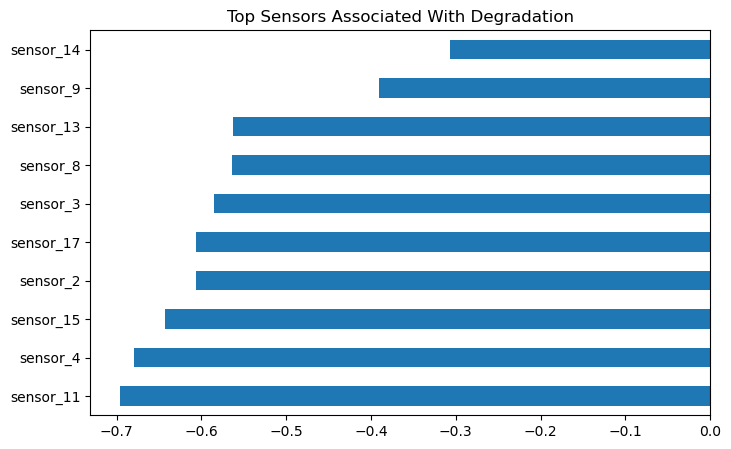

In [25]:
import matplotlib.pyplot as plt

correlations[
    correlations.index.str.contains("sensor")
].head(10).plot(
    kind="barh",
    figsize=(8,5)
)

plt.title(
    "Top Sensors Associated With Degradation"
)

plt.show()

In [26]:
important_sensors = [
    "sensor_11",
    "sensor_4",
    "sensor_15",
    "sensor_2",
    "sensor_17",
    "sensor_3",
    "sensor_8",
    "sensor_13"
]

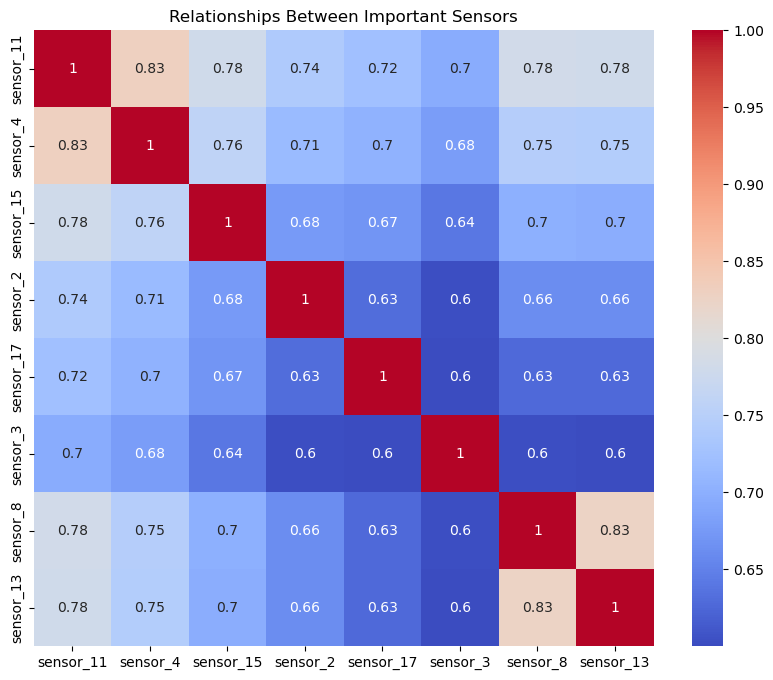

In [27]:
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    train_df[important_sensors].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Relationships Between Important Sensors"
)

plt.show()

In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [29]:
sensor_cols = [
    col for col in train_df.columns
    if "sensor" in col
]

X = train_df[sensor_cols]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [30]:
pca = PCA()

X_pca = pca.fit_transform(X_scaled)

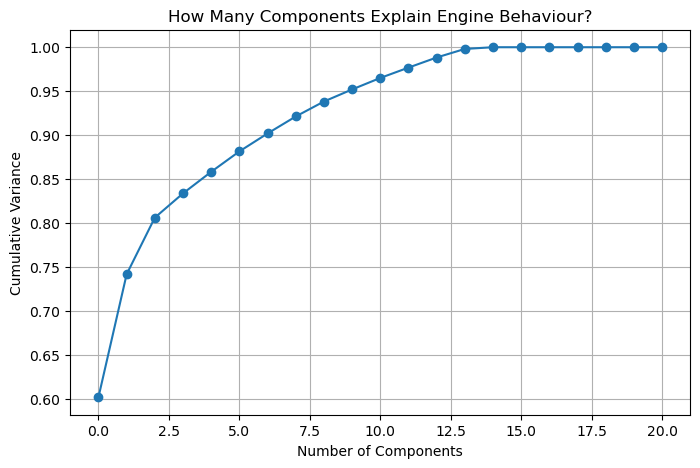

In [31]:
import numpy as np
import matplotlib.pyplot as plt

explained = np.cumsum(
    pca.explained_variance_ratio_
)

plt.figure(figsize=(8,5))

plt.plot(
    explained,
    marker='o'
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")

plt.title(
    "How Many Components Explain Engine Behaviour?"
)

plt.grid()

plt.show()

In [32]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=sensor_cols,
    columns=[
        f"PC{i+1}"
        for i in range(len(sensor_cols))
    ]
)

loadings["PC1"].sort_values(
    ascending=False
).head(10)

sensor_11    0.308709
sensor_4     0.300590
sensor_15    0.286543
sensor_8     0.281276
sensor_13    0.280940
sensor_2     0.272745
sensor_17    0.268728
sensor_3     0.259608
sensor_9     0.105348
sensor_14    0.065960
Name: PC1, dtype: float64

In [33]:
loadings["PC1"].sort_values().head(10)

sensor_12   -3.038567e-01
sensor_7    -2.978567e-01
sensor_21   -2.831388e-01
sensor_20   -2.822094e-01
sensor_18   -0.000000e+00
sensor_10   -0.000000e+00
sensor_1    -0.000000e+00
sensor_5    -0.000000e+00
sensor_19    1.368456e-48
sensor_16    1.848893e-32
Name: PC1, dtype: float64

In [34]:
health_index = X_pca[:,0]

train_df["health_index"] = health_index

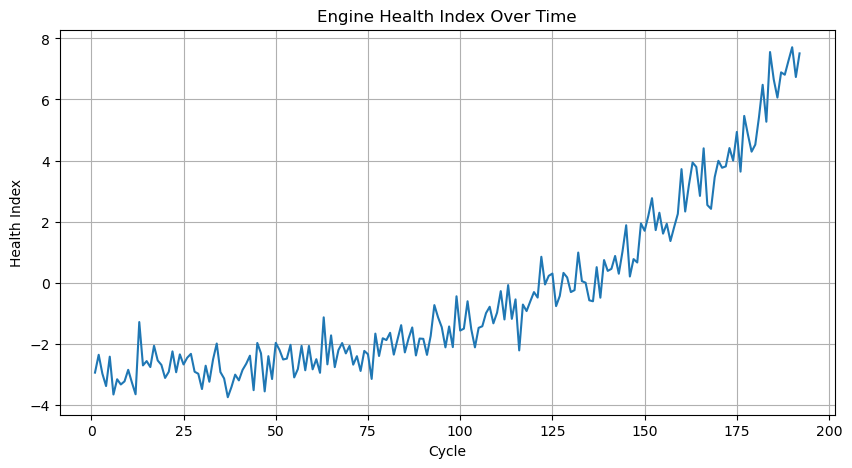

In [35]:
engine1 = train_df[
    train_df["engine_id"] == 1
]

plt.figure(figsize=(10,5))

plt.plot(
    engine1["cycle"],
    engine1["health_index"]
)

plt.title(
    "Engine Health Index Over Time"
)

plt.xlabel("Cycle")
plt.ylabel("Health Index")

plt.grid()

plt.show()

In [36]:
from scipy.stats import pearsonr

corr, p = pearsonr(
    train_df["health_index"],
    train_df["RUL"]
)

print("Correlation:", corr)

Correlation: -0.7411767126939035


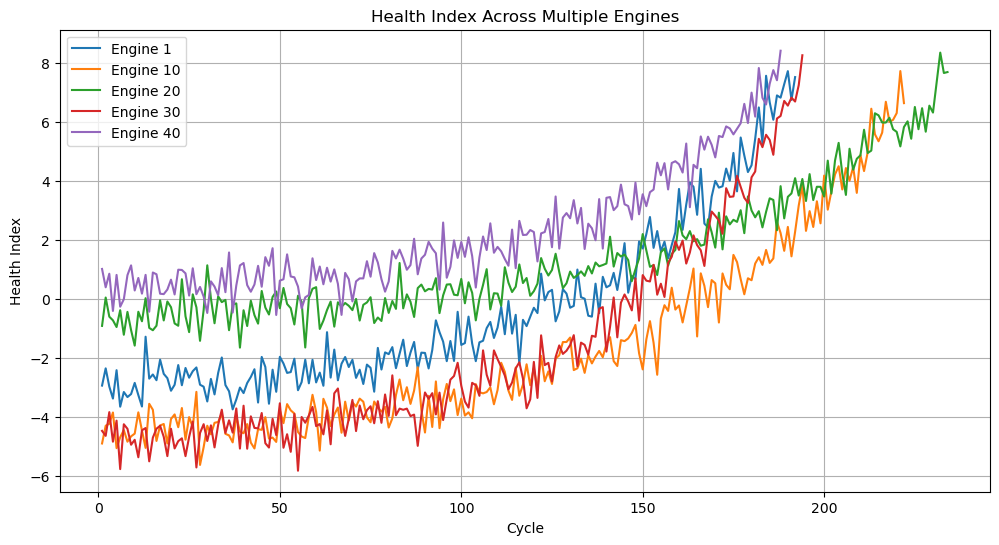

In [38]:
plt.figure(figsize=(12,6))

for engine in [1,10,20,30,40]:
    
    temp = train_df[
        train_df["engine_id"] == engine
    ]
    
    plt.plot(
        temp["cycle"],
        temp["health_index"],
        label=f"Engine {engine}"
    )

plt.legend()

plt.xlabel("Cycle")
plt.ylabel("Health Index")

plt.title(
    "Health Index Across Multiple Engines"
)

plt.grid()

plt.show()

In [39]:
train_df["risk_zone"] = pd.qcut(
    train_df["health_index"],
    q=4,
    labels=[
        "Healthy",
        "Monitor",
        "Warning",
        "Critical"
    ]
)

train_df["risk_zone"].value_counts()

risk_zone
Healthy     5158
Monitor     5158
Critical    5158
Warning     5157
Name: count, dtype: int64